## What is the most optimal skill to learn for Data Analysts

#### Methology
1. Group skills to determine median salary and likelihood of beeing in posting
2. Visualize median salary vs percent skill demanded
3. (Optional) Determine if certain skill are more prevalent

In [88]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
from matplotlib import cm
import ast
import seaborn as sns

# Loading Data
df = pd.read_csv('C:/Users/david/Desktop/job_postings_flat.csv')

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [89]:
df_DA_Ger = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'Germany')].copy()

In [90]:
df_DA_Ger = df_DA_Ger.dropna(subset='salary_year_avg')

df_DA_Ger_expl = df_DA_Ger.explode('job_skills')

df_DA_Ger_expl[['salary_year_avg', 'job_skills']].head()

,salary_year_avg,job_skills
46268,102500.0,sql
46268,102500.0,tableau
46268,102500.0,atlassian
54144,166419.5,python
54144,166419.5,nosql


In [91]:
df_skills = df_DA_Ger_expl.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)

df_skills = df_skills.rename(columns={'count': 'skill_count', 'median': 'median_salary'})

job_count = len(df_DA_Ger)

df_skills['skill_percent'] = df_skills['skill_count'] / job_count * 100

df_skills



,skill_count,median_salary,skill_percent
job_skills,,,
sql,30,100250.00,45.454545
python,26,103325.00,39.393939
tableau,15,100500.00,22.727273
spark,10,105587.50,15.151515
excel,9,90000.00,13.636364
go,8,52014.00,12.121212
r,8,88033.75,12.121212
looker,7,60000.00,10.606061
power bi,6,93200.00,9.090909


In [92]:
skill_percentage = 5

df_skills_high_demand = df_skills[df_skills['skill_percent'] > skill_percentage]

df_skills_high_demand

,skill_count,median_salary,skill_percent
job_skills,,,
sql,30,100250.00,45.454545
python,26,103325.00,39.393939
tableau,15,100500.00,22.727273
spark,10,105587.50,15.151515
excel,9,90000.00,13.636364
go,8,52014.00,12.121212
r,8,88033.75,12.121212
looker,7,60000.00,10.606061
power bi,6,93200.00,9.090909


In [93]:
df_technology = df['job_type_skills'].copy()

df_technology = df_technology.drop_duplicates()

df_technology = df_technology.dropna()

technology_dict = {}

for row in df_technology:
    row_dict = ast.literal_eval(row)
    for key, value in row_dict.items():
        if key in technology_dict:
            technology_dict[key] += value
        else:
            technology_dict[key] = value

for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

In [94]:
df_technology = pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills'])

df_technology = df_technology.explode('skills')

df_technology

,technology,skills
0,analyst_tools,ms access
0,analyst_tools,visio
0,analyst_tools,ssis
0,analyst_tools,ssrs
0,analyst_tools,sas
...,...,...
9,sync,rocketchat
9,sync,ringcentral
9,sync,microsoft teams
9,sync,mattermost


In [95]:
df_plot = df_skills_high_demand.merge(df_technology, left_on='job_skills', right_on='skills')

df_plot = df_plot.set_index('skills')

13 [-0.82030489 -0.32979226]
14 [-0.18696692  0.01543831]


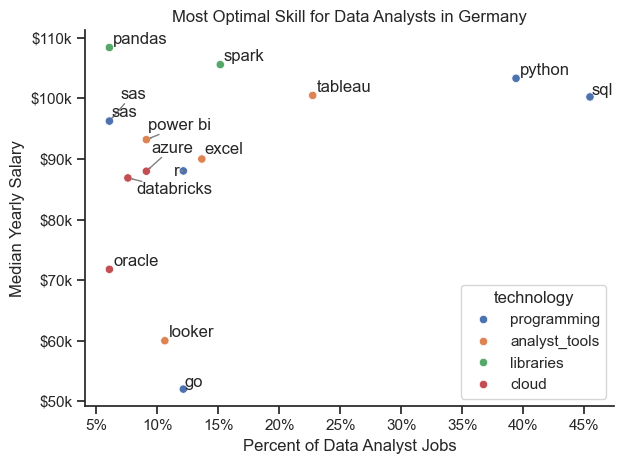

In [96]:
from adjustText import adjust_text

sns.scatterplot(
    data=df_plot,
    x='skill_percent',
    y='median_salary',
    hue='technology'
)

sns.despine()
sns.set_theme(style='ticks')

texts = []
for i in range(len(df_plot)):
    texts.append(plt.text(
        df_plot['skill_percent'].iloc[i], 
        df_plot['median_salary'].iloc[i], 
        df_plot.index[i]  
    ))

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))


from matplotlib.ticker import PercentFormatter
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}k'))
plt.gca().xaxis.set_major_formatter(PercentFormatter(decimals=0))


plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal Skill for Data Analysts in Germany')

plt.tight_layout()
plt.show()
